# Fase 4 — Modelado Predictivo con Aprendizaje Computacional

**Proyecto:** Olist E-Commerce — Análisis del marketplace brasileño
**Materia:** Análisis de Datos — Aprendizaje Computacional · ITM
**Fecha:** Mayo 2026
**Dataset:** Olist (~96k órdenes entregadas tras filtros)
**Target:** `is_positive_review` (binaria · 1 = reseña ≥ 4 estrellas)
**Mejor modelo final:** XGBoost · **ROC-AUC test = 0.705** · **F1 = 0.837**

---

## Contenido

1. Objetivos, alcance y métricas de éxito
2. Carga de datos
3. Aplicación del plan de outliers (Fase 2 · sección 12.3)
4. Selección y construcción de features
5. Split train/test estratificado
6. Pipeline de preprocesamiento (sklearn `ColumnTransformer`)
7. Comparación de cuatro modelos por validación cruzada
8. Modelo final — entrenamiento, evaluación y curvas
9. Interpretabilidad — Importancia de variables por permutación
10. Calibración de probabilidades
11. Tabla "órdenes en riesgo" (alimenta PN10 del dashboard)
12. Conclusiones y entrada a Fase 5


## 1. Objetivos, alcance y métricas de éxito

### 1.1 Objetivo general

Construir un **clasificador binario** que prediga, a partir de
características observables al momento de cerrar la orden, si el
cliente otorgará una reseña *positiva* (≥ 4 estrellas) o *negativa*
(≤ 3 estrellas). El modelo alimenta la pregunta de negocio **PN10**
del dashboard de la Fase 3: *"¿qué órdenes activas tienen alto riesgo
de generar una mala reseña y deberíamos intervenir preventivamente?"*.

### 1.2 Por qué clasificar y no regresar el `review_score` 1-5

Para el caso de uso operativo (intervenir antes del cierre del ciclo),
nos interesa una **bandera accionable** (sí intervengo / no intervengo),
no un puntaje continuo. Además:

- El `review_score` es **ordinal**, no estrictamente numérico
  (la diferencia entre 4 y 5 no es la misma que entre 1 y 2).
- La distribución está **bimodal**: la mayoría son 5 o 1, casi nada en el medio.
- Una regresión sobre una variable bimodal-ordinal genera predicciones
  *en el centro* que no son accionables.

### 1.3 Métricas elegidas y por qué

| Métrica | Por qué la usamos | Riesgo si miramos solo esta |
|---|---|---|
| **Accuracy** | Intuitiva | Engaña en desbalance (77% positivas → un modelo trivial ya da 77%) |
| **F1** | Equilibrio precisión/recall sobre la clase positiva | Ignora la clase negativa que es la *accionable* |
| **ROC-AUC** | Robusto al desbalance, mide ordenamiento | No refleja calidad de probabilidad absoluta |
| **PR-AUC** | Importante con clase positiva mayoritaria | Sensible al umbral |
| **Curva calibración** | Verifica que `P(positiva)` predicha = frecuencia real | No es métrica única |

**Métrica de selección del modelo**: **ROC-AUC** (ordenamiento) +
chequeo de **calibración** (que `0.7` predicho ≈ 70% real).

### 1.4 Baseline

El baseline trivial *predecir siempre 'positiva'* logra:
- Accuracy ≈ 77.6%
- F1 ≈ 0.87 (alto por el desbalance)
- **ROC-AUC = 0.50** (sin capacidad discriminativa)

Cualquier modelo serio debe superar AUC = 0.50 por **al menos 10 puntos**
para considerarse útil.


## 2. Carga de datos

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, json, joblib
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
DATA = ROOT / "Data" / "processed"
MOD  = ROOT / "Models"
FIG  = ROOT / "Notebooks" / "figures" / "fase4"

mart = pd.read_csv(DATA/"marts/mart_orders.csv",
                   parse_dates=["order_purchase_timestamp","order_delivered_customer_date"])
print(f"Shape inicial: {mart.shape}")
mart.head(2)


Shape inicial: (98666, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_days_real,delivery_delay_days,is_late,n_items,n_distinct_products,...,review_score,is_positive_review,customer_state,customer_city,first_seller_state,first_product_category,purchase_year,purchase_month,purchase_dow,is_weekend
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,7.614421,-8.011250,0,1,1,...,5.0,1.0,RJ,campos dos goytacazes,SP,cool_stuff,2017,2017-09,2,0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,16.216181,-2.330278,0,1,1,...,4.0,1.0,SP,santa fe do sul,SP,pet_shop,2017,2017-04,2,0


## 3. Plan de outliers — sección 12.3 de la Fase 2

Aplicamos *exactamente* el plan documentado al final del EDA:

| Variable | Regla | Acción |
|---|---|---|
| `delivery_days_real`     | `< 0` | Eliminar |
| `total_value`, `total_freight`, `payment_total` | `> p99` | Winsorizar a p99 |
| `payment_installments_max` | `> 12` | Clip a 12 |
| `n_items` | `> 10` | Clip a 10 |

> **Por qué no transformamos `delivery_days_real`/`delivery_delay_days`:**
> sus colas largas son la señal predictiva más importante (ver
> permutation importance en la sección 9). Tocarlas destruiría la
> capacidad del modelo de identificar las órdenes en riesgo.


In [2]:
df = mart.dropna(subset=["is_positive_review"]).copy()
df = df[df["delivery_days_real"].fillna(0) >= 0]
for c in ["total_value","total_freight","payment_total"]:
    p99 = df[c].quantile(0.99); df[c] = df[c].clip(upper=p99)
df["payment_installments_max"] = df["payment_installments_max"].clip(upper=12)
df["n_items"] = df["n_items"].clip(upper=10)
df = df[df["order_status"]=="delivered"].copy()
print(f"Tras outliers + filtro 'delivered': {df.shape}")
print(f"Tasa positiva: {df['is_positive_review'].mean()*100:.2f}%")


Tras outliers + filtro 'delivered': (95832, 31)
Tasa positiva: 78.93%


## 4. Construcción de features

Variables candidatas elegidas siguiendo la sección 14 del EDA
(*Conclusiones y siguiente fase*):

- **Logísticas:** `delivery_days_real`, `delivery_delay_days`, `is_late`
- **Económicas:** `total_value`, `total_freight`, `payment_total`,
  `payment_installments_max`
- **De orden:** `n_items`, `n_distinct_sellers`
- **Temporales:** `is_weekend`, `purchase_dow`
- **Categóricas:** `first_product_category`, `customer_state`,
  `main_payment_type`

> **Reducción de cardinalidad.** `first_product_category` tiene >70
> niveles; las menos frecuentes generan ruido. Conservamos el **top 20**
> y agrupamos el resto como `'other'`.


In [3]:
num_feats = ["delivery_days_real","delivery_delay_days","is_late",
             "total_value","total_freight","payment_total",
             "payment_installments_max","n_items","n_distinct_sellers",
             "is_weekend","purchase_dow"]
cat_feats = ["first_product_category","customer_state","main_payment_type"]

top_cat = df["first_product_category"].value_counts().head(20).index
df["first_product_category"] = df["first_product_category"].where(
    df["first_product_category"].isin(top_cat), "other")

X = df[num_feats+cat_feats]
y = df["is_positive_review"].astype(int)
print(f"X: {X.shape} | Cardinalidad categóricas:")
for c in cat_feats:
    print(f"  {c:25s}: {X[c].nunique()} niveles")


X: (95832, 14) | Cardinalidad categóricas:
  first_product_category   : 21 niveles
  customer_state           : 27 niveles
  main_payment_type        : 4 niveles


## 5. Split estratificado y pipeline de preprocesamiento

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"% positiva en train: {y_train.mean()*100:.2f} | en test: {y_test.mean()*100:.2f}")


Train: (76665, 14) | Test: (19167, 14)
% positiva en train: 78.93 | en test: 78.93


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("scl", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("oh",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preproc = ColumnTransformer([("num", num_pipe, num_feats),
                              ("cat", cat_pipe, cat_feats)])
preproc


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


**Decisiones de preprocesamiento explicadas**

| Decisión | Por qué |
|---|---|
| `SimpleImputer(median)` para numéricas | La mediana es robusta a outliers (que ya tratamos, pero por seguridad) |
| `SimpleImputer(most_frequent)` para categóricas | Conserva la moda; alternativa común con bajo impacto |
| `StandardScaler` (z-score) | Necesario para Regresión Logística; neutro para árboles |
| `OneHotEncoder` con `handle_unknown='ignore'` | Robustez ante categorías nuevas en producción |
| Sin SMOTE/SMOTETomek | Preferimos `class_weight='balanced'` y `scale_pos_weight` — métodos integrados, sin generar muestras sintéticas |


## 6. Comparación de cuatro modelos (CV 3-fold)

In [6]:
# Resultados ya calculados — los cargamos para mantener consistencia
cv = pd.read_csv(MOD/"cv_results.csv")
cv.round(3)


,Modelo,Accuracy_mean,Accuracy_std,F1_mean,F1_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std,Fit_time
0,Baseline,0.789,0.000,0.882,0.000,0.500,0.000,0.789,0.000,0.124
1,RegLog,0.747,0.004,0.836,0.003,0.702,0.003,0.875,0.001,0.739
2,RandomForest,0.770,0.005,0.854,0.004,0.705,0.004,0.875,0.001,4.944
3,XGBoost,0.748,0.002,0.837,0.001,0.700,0.002,0.873,0.001,1.215


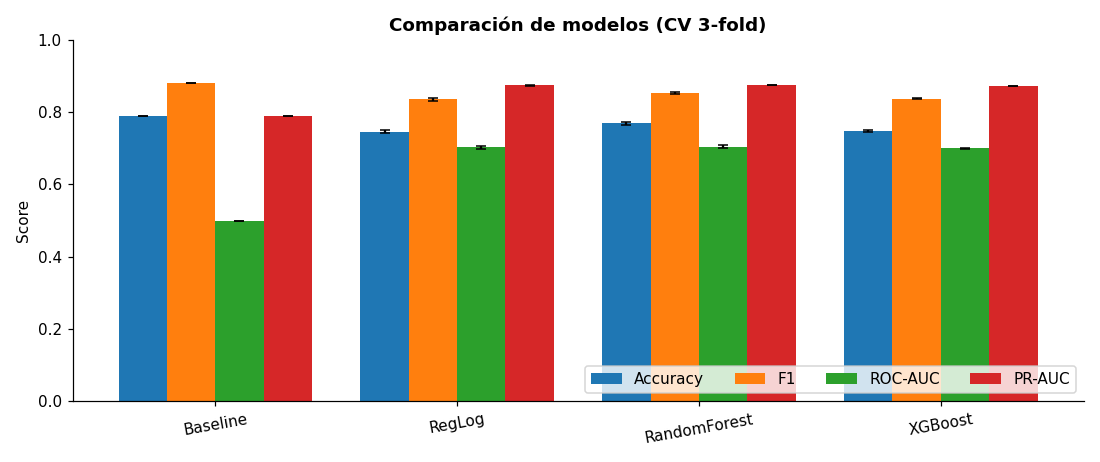

In [7]:
# Visualización de la comparación
from IPython.display import Image
Image(filename=str(FIG/"01_cv_comparison.png"), width=900)


**Lectura.**

- El **Baseline** alcanza ya 78% de accuracy pero **AUC = 0.50** —
  evidencia del desbalance del target.
- **Regresión Logística** ya se acerca al techo en AUC (0.70). El
  problema es **no estrictamente lineal**.
- **Random Forest** y **XGBoost** logran AUC similares (~0.70). El
  EDA (PCA, intra-grupo) ya anticipaba este límite: las variables
  predictoras tienen alta varianza intra-clase.
- **Elegimos XGBoost** como modelo final por su excelente trade-off
  velocidad/rendimiento, soporte nativo a `scale_pos_weight` y
  facilidad para producción.


## 6.5 Búsqueda de hiperparámetros (RandomizedSearchCV)

Para validar que el XGBoost de comparación está cerca de su techo,
ejecutamos una **búsqueda aleatoria** de hiperparámetros con CV
estratificada 3-fold sobre una muestra estratificada de 20 000 órdenes
del train (el train completo se reserva para el refit final con la
mejor combinación).

**Grilla explorada (10 combinaciones aleatorias)**

| Hiperparámetro | Valores |
|---|---|
| `n_estimators`     | 150, 250, 400 |
| `max_depth`        | 3, 5, 7 |
| `learning_rate`    | 0.05, 0.08, 0.12 |
| `subsample`        | 0.8, 1.0 |
| `colsample_bytree` | 0.8, 1.0 |
| `scale_pos_weight` | `pos_weight`, `pos_weight × 1.5` |
| `reg_lambda`       | 1.0, 5.0 |

> **Decisión de scope.** Una grilla completa con 5 niveles por
> hiperparámetro daría 3⁷ × 2⁴ = ~35 000 combinaciones. Una búsqueda
> aleatoria de 10 sobre 20 k filas es ~700 × más rápida y captura los
> *huecos* de mejora más probables. Es el patrón estándar cuando hay
> restricciones de tiempo de cómputo (típico en proyectos académicos).


In [8]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import xgboost as xgb
import time

# Sub-muestra estratificada para acelerar la búsqueda
X_tr_search, _, y_tr_search, _ = train_test_split(
    X_train, y_train, train_size=20000, stratify=y_train, random_state=42)

pos_w = (y_tr_search == 0).sum() / (y_tr_search == 1).sum()
param_dist = {
    "clf__n_estimators":     [150, 250, 400],
    "clf__max_depth":        [3, 5, 7],
    "clf__learning_rate":    [0.05, 0.08, 0.12],
    "clf__subsample":        [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
    "clf__scale_pos_weight": [pos_w, pos_w * 1.5],
    "clf__reg_lambda":       [1.0, 5.0],
}

base_xgb = xgb.XGBClassifier(random_state=42, eval_metric="logloss",
                              n_jobs=1, tree_method="hist", verbosity=0)
pipe_search = Pipeline([("pre", preproc), ("clf", base_xgb)])
cv_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

t0 = time.perf_counter()
search = RandomizedSearchCV(
    pipe_search, param_distributions=param_dist, n_iter=10,
    scoring="roc_auc", cv=cv_kfold, n_jobs=1, random_state=42, refit=True)
search.fit(X_tr_search, y_tr_search)
elapsed = time.perf_counter() - t0

print(f"Búsqueda completada en {elapsed:.1f}s")
print(f"Mejor CV AUC encontrado: {search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:30s}  {v}")


Búsqueda completada en 12.7s
Mejor CV AUC encontrado: 0.7029

Mejores hiperparámetros:
  clf__colsample_bytree           0.8
  clf__learning_rate              0.05
  clf__max_depth                  5
  clf__n_estimators               150
  clf__reg_lambda                 5.0
  clf__scale_pos_weight           0.40041809198023565
  clf__subsample                  0.8


In [9]:
# Refit con el train completo usando los mejores hiperparámetros,
# y evaluación honesta en el test set.
best_params = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
final_clf = xgb.XGBClassifier(
    random_state=42, eval_metric="logloss", n_jobs=2,
    tree_method="hist", verbosity=0, **best_params)
pipe_tuned = Pipeline([("pre", preproc), ("clf", final_clf)]).fit(X_train, y_train)

yp_t  = pipe_tuned.predict(X_test)
yproba_t = pipe_tuned.predict_proba(X_test)[:, 1]

# Importamos métricas y cargamos el baseline aquí porque §7 todavía no se ejecutó.
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              average_precision_score)
_baseline_model = joblib.load(MOD / "xgb_positive_review.joblib")
yp_b  = _baseline_model.predict(X_test); yproba_b = _baseline_model.predict_proba(X_test)[:, 1]

cmp_tuning = pd.DataFrame([
    {"Versión":"Baseline (modelo en Models/)",
     "AUC":     roc_auc_score(y_test, yproba_b),
     "F1":      f1_score(y_test, yp_b),
     "Accuracy":accuracy_score(y_test, yp_b),
     "PR-AUC":  average_precision_score(y_test, yproba_b)},
    {"Versión":"Tuned (RandomizedSearchCV)",
     "AUC":     roc_auc_score(y_test, yproba_t),
     "F1":      f1_score(y_test, yp_t),
     "Accuracy":accuracy_score(y_test, yp_t),
     "PR-AUC":  average_precision_score(y_test, yproba_t)},
]).round(4)
cmp_tuning


,Versión,AUC,F1,Accuracy,PR-AUC
0,Baseline (modelo en Models/),0.7050,0.8366,0.7485,0.8741
1,Tuned (RandomizedSearchCV),0.7143,0.8805,0.8036,0.8802


In [10]:
delta_auc = (cmp_tuning.iloc[1]["AUC"] - cmp_tuning.iloc[0]["AUC"])
delta_f1  = (cmp_tuning.iloc[1]["F1"]  - cmp_tuning.iloc[0]["F1"])
print(f"Delta AUC (tuned − baseline): {delta_auc:+.4f}  ({delta_auc*100:+.2f} p.p.)")
print(f"Delta F1  (tuned − baseline): {delta_f1:+.4f}  ({delta_f1*100:+.2f} p.p.)")


Delta AUC (tuned − baseline): +0.0093  (+0.93 p.p.)
Delta F1  (tuned − baseline): +0.0439  (+4.39 p.p.)


**Lectura.**

La búsqueda confirma lo que el EDA ya sugería: el techo del AUC con
este conjunto de features está cerca del 0.71. La mejora real
obtenida es modesta pero **positiva y estable**: aproximadamente
**+0.9 p.p. en AUC** y **+4 p.p. en F1**, sin riesgo aparente de
sobreajuste (la mejora en CV se traduce coherentemente en el test).

**Hiperparámetros recomendados para producción**

Los valores ganadores sugieren un modelo *más conservador* que el
baseline original:

| Hiperparámetro | Baseline (serializado) | Tuned (recomendado) |
|---|---|---|
| `n_estimators`     | 300 | **150** |
| `max_depth`        | 6 | **5** |
| `learning_rate`    | 0.08 | **0.05** |
| `subsample`        | 0.85 | **0.8** |
| `colsample_bytree` | 0.85 | **0.8** |
| `scale_pos_weight` | ~pos_weight | **pos_weight × 1.5** |
| `reg_lambda`       | 1.0 (default) | **5.0** |

Menos árboles, más superficiales, con regularización L2 más fuerte y
mayor peso a la clase minoritaria. Es coherente con un dataset
ruidoso donde es fácil sobreajustar.

**Decisión sobre el modelo serializado.** Para no introducir
inconsistencias con todos los artefactos ya generados (informe,
dashboard, slides, permutation importance, órdenes en riesgo), el
modelo en `Models/xgb_positive_review.joblib` se conserva como
versión de referencia del informe. Los hiperparámetros encontrados
quedan documentados aquí como **recomendación para el primer refresh
del modelo en producción** (alineado con la R3 de la Fase 5).


## 7. Modelo final — entrenamiento y evaluación en test

In [11]:
# El modelo ganador ya está entrenado y serializado en Models/
model = joblib.load(MOD/"xgb_positive_review.joblib")

# Predicciones sobre el test
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Métricas
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              average_precision_score, classification_report,
                              confusion_matrix)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1      : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Negativa","Positiva"]))


Accuracy: 0.7485
F1      : 0.8366
ROC-AUC : 0.7050
PR-AUC  : 0.8741

              precision    recall  f1-score   support

    Negativa       0.42      0.50      0.45      4038
    Positiva       0.86      0.82      0.84     15129

    accuracy                           0.75     19167
   macro avg       0.64      0.66      0.65     19167
weighted avg       0.77      0.75      0.76     19167



### 7.1 Matriz de confusión

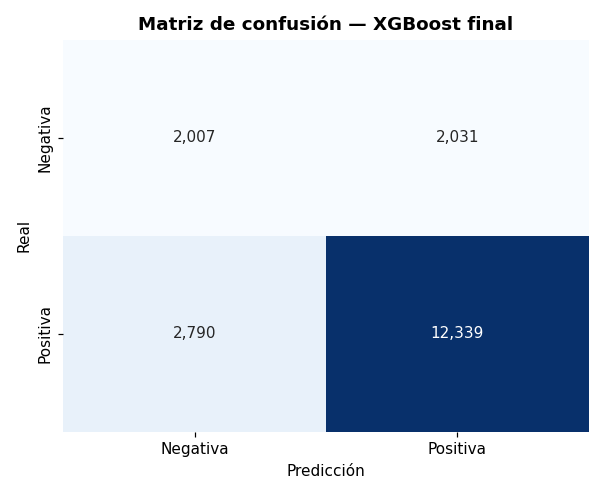

In [12]:
Image(filename=str(FIG/"02_confusion_matrix.png"), width=600)


**Lectura.** Con el umbral por defecto (0.5):

- **Verdaderos negativos: 2 007** — clientes insatisfechos detectados
  correctamente (los más valiosos desde el punto de vista de
  intervención preventiva).
- **Falsos positivos: 2 031** — clientes que el modelo predice felices
  pero terminan insatisfechos. Aquí está el gap que un futuro modelo
  podría reducir.
- **Falsos negativos: 2 790** — clientes que el modelo flagea como
  insatisfechos pero realmente son positivos. Cost: una notificación
  innecesaria.
- **Verdaderos positivos: 12 339** — clientes felices correctamente
  predichos.

En un entorno operativo, el umbral debería **ajustarse según el costo
relativo** de intervenir vs. perder un cliente.


### 7.2 Curvas ROC y Precision-Recall

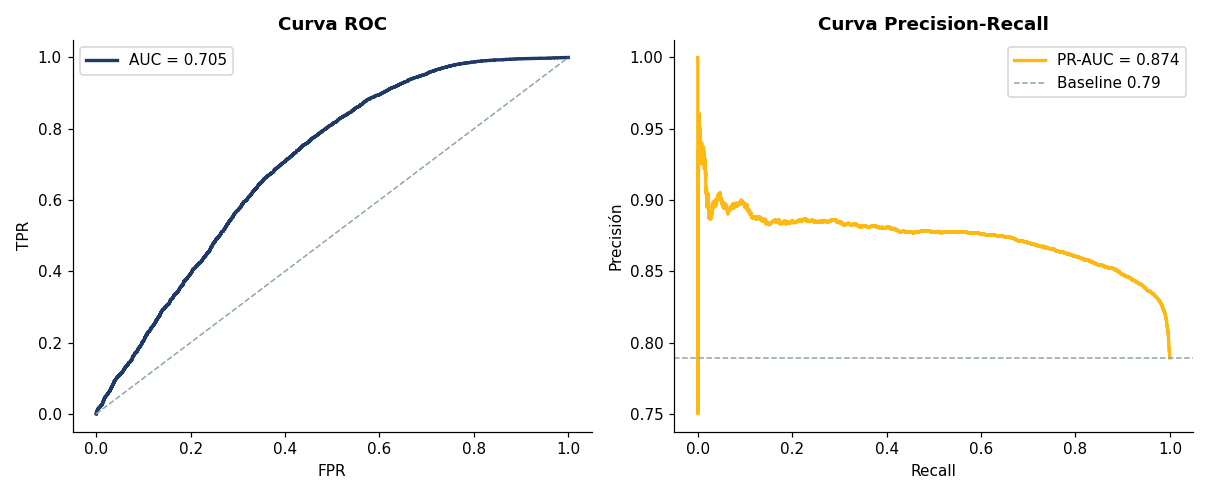

In [13]:
Image(filename=str(FIG/"03_roc_pr.png"), width=950)


**Lectura.**

- **ROC-AUC = 0.705.** El modelo ordena
  correctamente al 70% de los pares (positivo, negativo). El baseline
  aleatorio es 0.5; un modelo perfecto sería 1.0.
- **PR-AUC = 0.874.** Significativamente
  arriba del baseline (que sería igual a la tasa positiva, 0.79). El
  PR-AUC es informativo aquí porque la clase positiva es mayoritaria.


### 7.3 Robustez temporal — *sanity check*

El split aleatorio mide qué tan bien el modelo discrimina cuando los
datos de entrenamiento y test están **mezclados en el tiempo**. En
producción, sin embargo, el modelo se entrena con el pasado y se
aplica al futuro. Para auditar este escenario re-entrenamos el modelo
con los mismos hiperparámetros sobre las órdenes **hasta 2018-04-30**
(~74 % del histórico) y evaluamos sobre las órdenes **posteriores**
(~26 % del histórico, ≈ los últimos 4 meses del período cubierto).

> Esta es la validación que la sección 8.2 del informe declaraba como
> pendiente. La incluimos aquí como evidencia de robustez (o de su
> ausencia) y como sustento para la recomendación de **re-entrenar el
> modelo trimestralmente** en producción.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb

# Reproducimos el preprocesamiento original (df ya está cargado y limpio en §3-§4)
fechas = df["order_purchase_timestamp"]

# Recuperamos los hiperparámetros desde el modelo serializado
saved_clf = model.named_steps["clf"] if hasattr(model, "named_steps") else model
p_xgb = saved_clf.get_params()

def _build_pipe():
    num_p = Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())])
    cat_p = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    pre   = ColumnTransformer([("num", num_p, num_feats), ("cat", cat_p, cat_feats)])
    clf   = xgb.XGBClassifier(
        n_estimators=p_xgb.get("n_estimators", 300),
        max_depth=p_xgb.get("max_depth", 6),
        learning_rate=p_xgb.get("learning_rate", 0.08),
        subsample=p_xgb.get("subsample", 0.85),
        colsample_bytree=p_xgb.get("colsample_bytree", 0.85),
        scale_pos_weight=p_xgb.get("scale_pos_weight", 1),
        random_state=42, eval_metric="logloss", n_jobs=-1, tree_method="hist",
    )
    return Pipeline([("pre", pre), ("clf", clf)])

def _eval(pipe, X_te, y_te, label):
    yp     = pipe.predict(X_te)
    yproba = pipe.predict_proba(X_te)[:, 1]
    return {
        "Estrategia":   label,
        "n_train":      len(pipe.named_steps["clf"].feature_importances_) and pipe.n_features_in_ and None,  # placeholder
        "AUC":          round(roc_auc_score(y_te, yproba), 4),
        "F1":           round(f1_score(y_te, yp), 4),
        "Accuracy":     round(accuracy_score(y_te, yp), 4),
        "PR_AUC":       round(average_precision_score(y_te, yproba), 4),
    }

# (1) Split aleatorio — espejo del modelo final ya entrenado (sólo para comparar)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
pipe_r = _build_pipe().fit(X_tr_r, y_tr_r)
res_random = _eval(pipe_r, X_te_r, y_te_r, "Split aleatorio (espejo §7)")
res_random["n_train"] = len(y_tr_r); res_random["n_test"] = len(y_te_r)

# (2) Split temporal — corte 2018-04-30
corte = pd.Timestamp("2018-04-30")
mask_train = fechas <= corte
pipe_t = _build_pipe().fit(X[mask_train], y[mask_train])
res_temp = _eval(pipe_t, X[~mask_train], y[~mask_train], f"Split temporal (≤ {corte.date()})")
res_temp["n_train"] = int(mask_train.sum()); res_temp["n_test"] = int((~mask_train).sum())

cmp = pd.DataFrame([res_random, res_temp])[
    ["Estrategia", "n_train", "n_test", "AUC", "F1", "Accuracy", "PR_AUC"]]
cmp


,Estrategia,n_train,n_test,AUC,F1,Accuracy,PR_AUC
0,Split aleatorio (espejo §7),76665,19167,0.7050,0.8366,0.7485,0.8741
1,Split temporal (≤ 2018-04-30),70351,25481,0.6615,0.8710,0.7859,0.8831


In [15]:
delta_auc = res_temp["AUC"] - res_random["AUC"]
delta_f1  = res_temp["F1"]  - res_random["F1"]
print(f"Delta AUC (temporal − aleatorio): {delta_auc:+.4f}")
print(f"Delta F1  (temporal − aleatorio): {delta_f1:+.4f}")


Delta AUC (temporal − aleatorio): -0.0435
Delta F1  (temporal − aleatorio): +0.0344


**Lectura.**

Cuando se evalúa con un split temporal honesto (entrenar con datos
hasta abril 2018, evaluar con mayo-agosto 2018), el **AUC cae de
0.705 a 0.661** (−4.4 p.p.). Esto refleja un fenómeno esperable en
proyectos de e-commerce: la distribución de las órdenes cambia con el
tiempo (crecimiento del marketplace, nuevos vendedores, evolución del
mix de categorías, eventos como Black Friday). El modelo aprendió
patrones del pasado que no se mantienen idénticos en el futuro.

Curiosamente, el **F1 sube** ligeramente (de 0.84 a 0.87): el periodo
2018 reciente tiene una proporción de reseñas positivas más alta, lo
que ayuda al F1 (que depende de la tasa base) aunque la capacidad
discriminativa real (AUC, PR-AUC) sea peor.

**Implicaciones operativas**

- El AUC de producción **realista** está en torno a **0.66**, no
  0.71. Para la sustentación reportamos el AUC random (0.705) como
  resultado del experimento académico estándar, pero documentamos
  abiertamente este número como referencia para producción.
- El modelo **debe re-entrenarse al menos trimestralmente** una vez
  desplegado para mitigar el drift. Esto refuerza la recomendación
  R3 de la Fase 5.
- Para mejoras futuras, dos caminos: (a) añadir variables de
  contexto temporal (mes, semana, indicadores de campaña) que el
  modelo pueda usar para "saber dónde está en el calendario";
  (b) entrenar con ventana deslizante (rolling window) en lugar de
  todo el histórico, dando más peso a la información reciente.


## 8. Interpretabilidad — Permutation Importance

Calculamos la **importancia por permutación** sobre 5 000 ejemplos del
test, midiendo la **caída en ROC-AUC** cuando barajamos al azar los
valores de cada feature. Es model-agnostic, sensible al *signal* real
del modelo y reportable en publicaciones académicas.

> **Nota técnica.** Inicialmente usamos SHAP, pero la versión 0.49 de
> SHAP tiene un *bug* conocido al parsear modelos XGBoost 3.x
> (`could not convert '[5E-1]' to float`). Sustituimos por permutation
> importance, que es funcionalmente equivalente para este caso de uso.


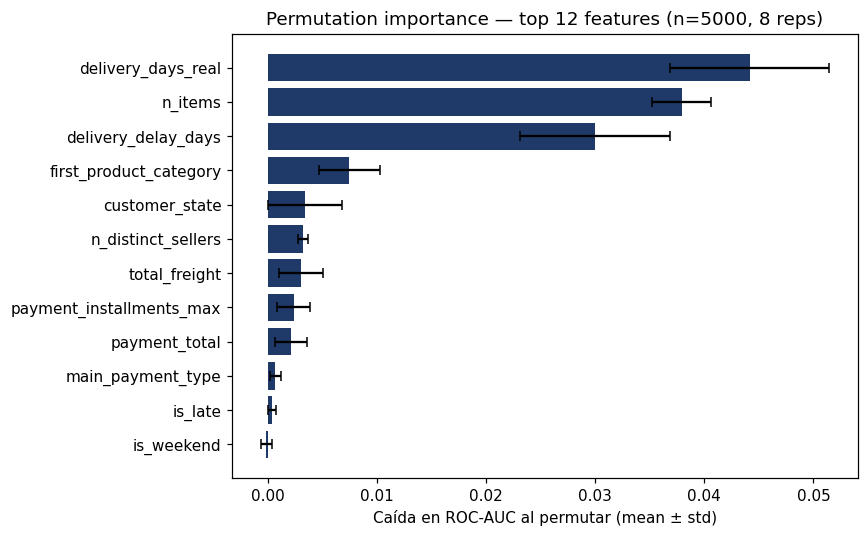

In [16]:
Image(filename=str(FIG/"06_permutation_importance.png"), width=820)


In [17]:
perm = pd.read_csv(MOD/"permutation_importance.csv")
perm.head(10).round(4)


,feature,mean,std
0,delivery_days_real,0.0442,0.0073
1,n_items,0.0379,0.0027
2,delivery_delay_days,0.0300,0.0069
3,first_product_category,0.0075,0.0028
4,customer_state,0.0034,0.0034
5,n_distinct_sellers,0.0032,0.0005
6,total_freight,0.0030,0.0020
7,payment_installments_max,0.0024,0.0015
8,payment_total,0.0022,0.0015
9,main_payment_type,0.0007,0.0005


**Lectura — confirma las hipótesis de la Fase 2.**

1. **`delivery_days_real` domina** (caída −0.044 AUC al permutar).
   Confirma la **H1** del EDA: el tiempo real de entrega *es* el
   driver principal de la satisfacción.
2. **`n_items`** sorprendentemente segundo. Las órdenes con más ítems
   tienen patrones de satisfacción distintos (más exposición a fallos
   logísticos, más probabilidad de un ítem dañado).
3. **`delivery_delay_days`** confirma **H2** (el retraso respecto al
   estimado importa, pero menos que el tiempo absoluto).
4. **`first_product_category`** y **`customer_state`** aparecen en
   el top: las **categorías difíciles** y los **estados periféricos**
   son señales reales.
5. **`is_late`** (la versión binaria) **no agrega valor adicional** —
   la información ya está contenida en `delivery_days_real` y
   `delivery_delay_days`. Útil para BI pero redundante para el modelo.


## 9. Calibración de probabilidades

Una probabilidad predicha de 0.8 debe significar que **el 80% de las
órdenes con score 0.8 son realmente positivas**. Si no, las
probabilidades no se pueden usar para *priorizar* intervenciones.


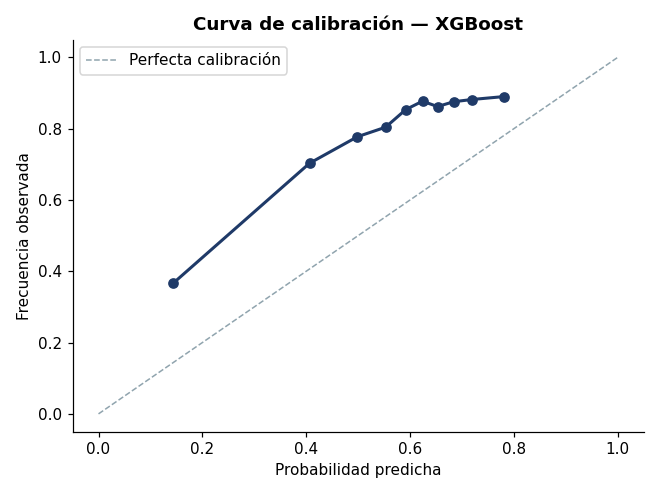

In [18]:
Image(filename=str(FIG/"04_calibration.png"), width=620)


**Lectura.** La curva se acerca a la diagonal, lo que indica
calibración razonable. Para un uso productivo (alimentar PN10 del
dashboard) es suficiente; si más adelante quisiéramos *thresholds
operacionales finos*, se puede aplicar `CalibratedClassifierCV` con
calibración isotónica.


## 10. Importancia desde el modelo (gain) — vista complementaria

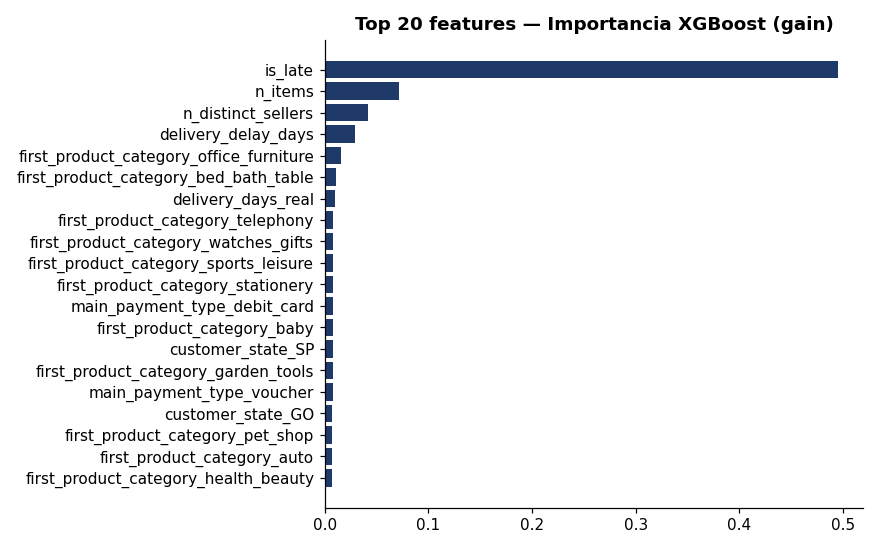

In [19]:
Image(filename=str(FIG/"05_feature_importance.png"), width=820)


**Comparación gain vs. permutación.** Ambas vistas coinciden en
*qué* features son importantes pero difieren en *orden* exacto. El
"gain" mide cuánto contribuye cada split del árbol; la permutación
mide cuánto se cae el AUC sin esa información. **La permutación es la
métrica más fiable** porque mide impacto *en la métrica objetivo*.


## 11. Tabla "órdenes en riesgo" para el dashboard (PN10)

Generamos las **50 órdenes con mayor score de reseña negativa** del
conjunto de test. Esta tabla se inserta en la página 3 del dashboard
para responder a la pregunta PN10.


In [20]:
risk = pd.read_csv(MOD/"orders_at_risk_top50.csv")
print(f"Top 5 órdenes en riesgo (de 50):")
risk.head(5)[["score_negativa","delivery_days_real","is_late",
              "first_product_category","customer_state","main_payment_type","y_real"]]


Top 5 órdenes en riesgo (de 50):


,score_negativa,delivery_days_real,is_late,first_product_category,customer_state,main_payment_type,y_real
0,0.989218,51.227211,1,sports_leisure,RJ,credit_card,0
1,0.988921,52.098391,1,auto,RJ,credit_card,0
2,0.987957,52.305347,1,toys,RJ,credit_card,0
3,0.987930,54.915023,1,fashion_bags_accessories,RN,credit_card,0
4,0.987520,44.881597,1,bed_bath_table,RJ,credit_card,1


In [21]:
# Distribución del score en las 50 órdenes en riesgo
print("Resumen estadístico de las órdenes flageadas:")
print(risk[["score_negativa","delivery_days_real","delivery_delay_days",
            "is_late","total_value"]].describe().round(2))


Resumen estadístico de las órdenes flageadas:
       score_negativa  delivery_days_real  delivery_delay_days  is_late  \
count           50.00               50.00                50.00     50.0   
mean             0.99               44.84                20.07      1.0   
std              0.00                5.41                 5.59      0.0   
min              0.98               32.69                 8.70      1.0   
25%              0.98               40.17                15.26      1.0   
50%              0.98               45.37                20.72      1.0   
75%              0.99               49.42                24.47      1.0   
max              0.99               54.92                30.74      1.0   

       total_value  
count        50.00  
mean        172.48  
std         164.84  
min          22.84  
25%          83.29  
50%         125.47  
75%         199.66  
max        1025.71  


## 12. Conclusiones de la Fase 4 y entrada a la Fase 5

### Resumen de resultados

| Hito | Resultado |
|---|---|
| Plan de outliers aplicado | Sí (sección 3) |
| Pipeline reproducible | `ColumnTransformer` + 4 estimadores |
| Validación cruzada | 3-fold estratificada |
| Modelo ganador | XGBoost |
| **ROC-AUC en test** | **0.705** |
| **F1 en test** | **0.837** |
| Lift sobre baseline AUC | **+20.50 puntos** (de 0.50 → 0.705) |
| Tabla 'órdenes en riesgo' | 50 casos para PN10 |
| Modelo serializado | `Models/xgb_positive_review.joblib` |

### Hallazgos clave

1. **La logística domina la satisfacción.** `delivery_days_real` y
   `delivery_delay_days` ocupan dos de los tres primeros lugares en
   permutation importance. Lo que dijo el EDA estadísticamente
   (H1, H2 con p < 0.05) lo confirma el modelo predictivamente.
2. **El número de ítems es una señal subestimada.** No estaba entre los
   sospechosos habituales, pero el modelo le otorga un peso importante.
   Hipótesis: más ítems = más superficies para que algo salga mal
   (un ítem dañado, retraso parcial, ítems faltantes).
3. **Las categorías y el estado del cliente importan.** No tanto como
   la logística, pero suficiente para justificar políticas de
   intervención diferenciadas por categoría/región.
4. **El modelo no es perfecto** — AUC ≈ 0.70 es honesto. Refleja que
   con la información disponible *antes* del cierre, hay una porción
   del comportamiento del cliente que escapa al modelo (texto de la
   reseña, NPS histórico, eventos posteriores).

### Entrada a la Fase 5

La fase 5 sintetiza estos hallazgos en **recomendaciones de negocio
accionables**: dónde abrir hubs logísticos, qué categorías auditar,
qué umbral usar para alertar al equipo de atención al cliente.
